In [21]:
from sklearn.manifold import TSNE
from sklearn.manifold import Isomap
import umap
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [22]:
df = pd.read_csv("C:/Users/maman/OneDrive/שולחן העבודה/dataset-stroke-cleaned1.csv")

In [23]:
# Converting to boolean 
df["ever_married"] = df["ever_married"].map({"Yes": 1, "No": 0})
df["Residence_type"] = df["Residence_type"].map({"Rural": 1, "Urban": 0})

In [24]:
# Combine features
X = df.drop('stroke', axis=1)
y = df['stroke']

In [25]:
# Division into types of variables
cat_cols = ['gender', 'work_type', 'smoking_status']
bin_cols = ['hypertension', 'heart_disease', 'Residence_type','ever_married']
num_cols = ['age', 'avg_glucose_level', 'bmi']

In [26]:
# Encode categorical features
ohe = OneHotEncoder(drop= None, sparse_output=False)
X_cat = ohe.fit_transform(X[cat_cols])

In [27]:
# Scale numerical features
scaler = StandardScaler()
X_num = scaler.fit_transform(X[num_cols])

In [28]:
X_bin = X[bin_cols].to_numpy()

In [29]:
# Concatenate all features
X_all = np.concatenate([X_bin, X_num, X_cat], axis=1)
y = np.array(y).astype(int)

C:\Users\maman\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\maman\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


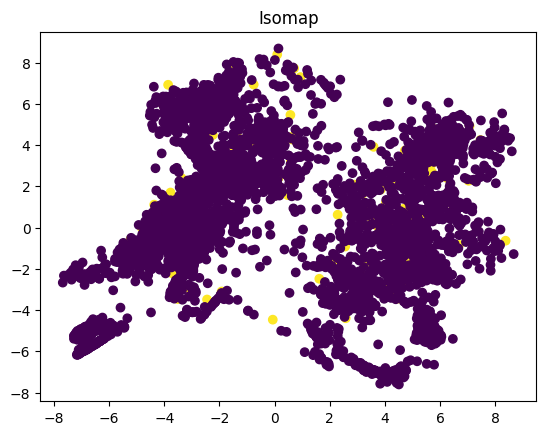

In [35]:
# Isomap
iso = Isomap(n_components=2)
XX = iso.fit_transform(X_all)
handles, _ = scatter.legend_elements()
plt.title("Isomap")
plt.scatter(XX[:,0],XX[:,1],c=y)

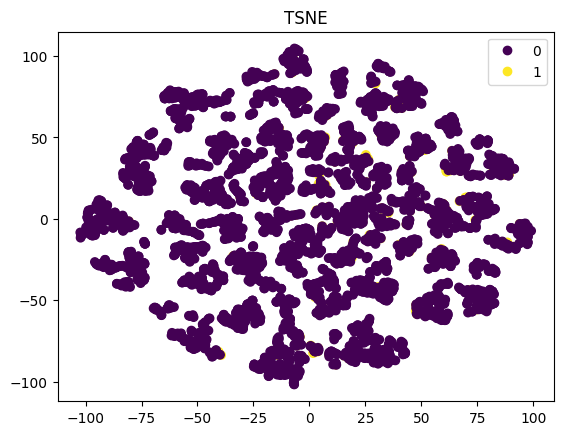

In [37]:
# TSNE
tsne = TSNE(n_components=2, perplexity=10)
Xtsne = tsne.fit_transform(X_all)
scatter=plt.scatter(Xtsne[:,0],Xtsne[:,1],c=y)
handles, _ = scatter.legend_elements()
plt.title("TSNE")
plt.legend(handles, range(10))

C:\Users\maman\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


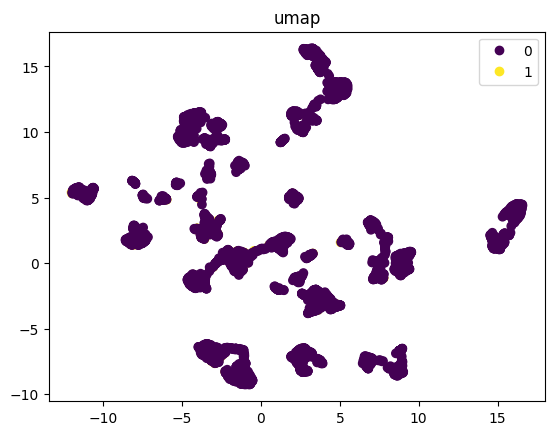

In [36]:
# umap
reducer = umap.UMAP()
Xu = reducer.fit_transform(X_all)
scatter=plt.scatter(Xu[:,0],Xu[:,1],c=y)
handles, _ = scatter.legend_elements()
plt.title("umap")
plt.legend(handles, range(10))